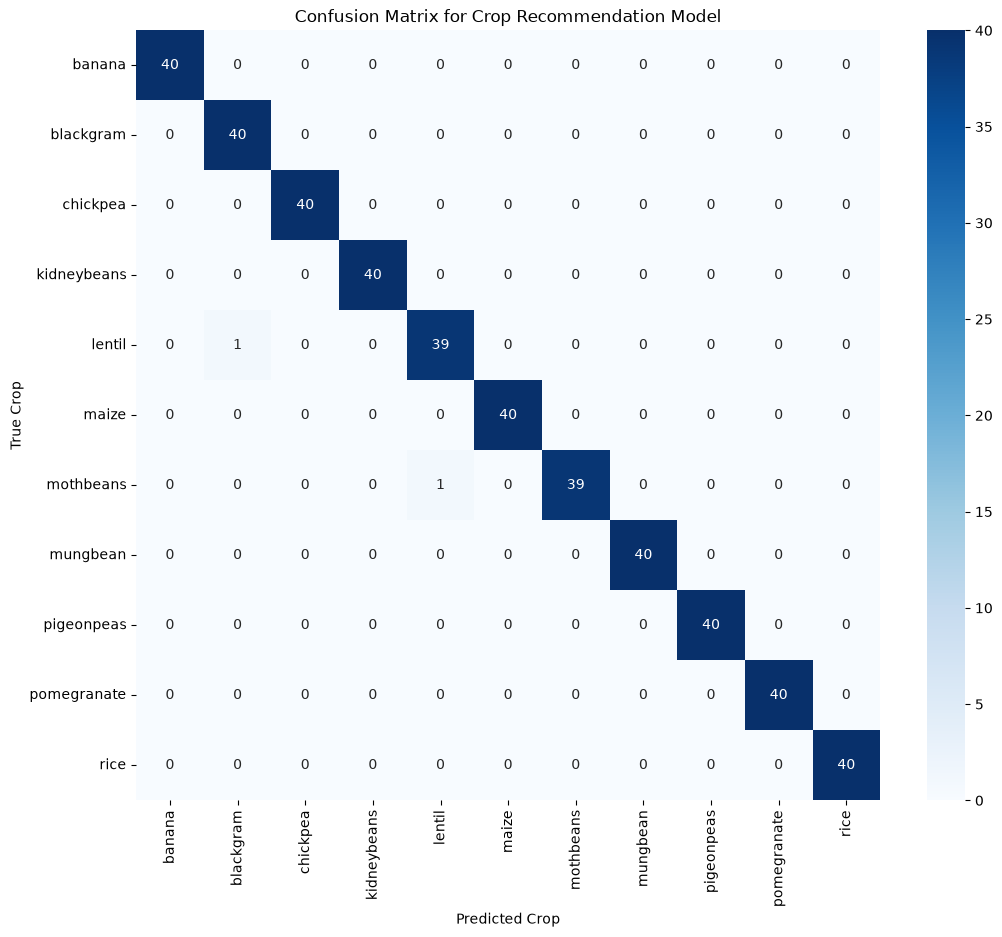

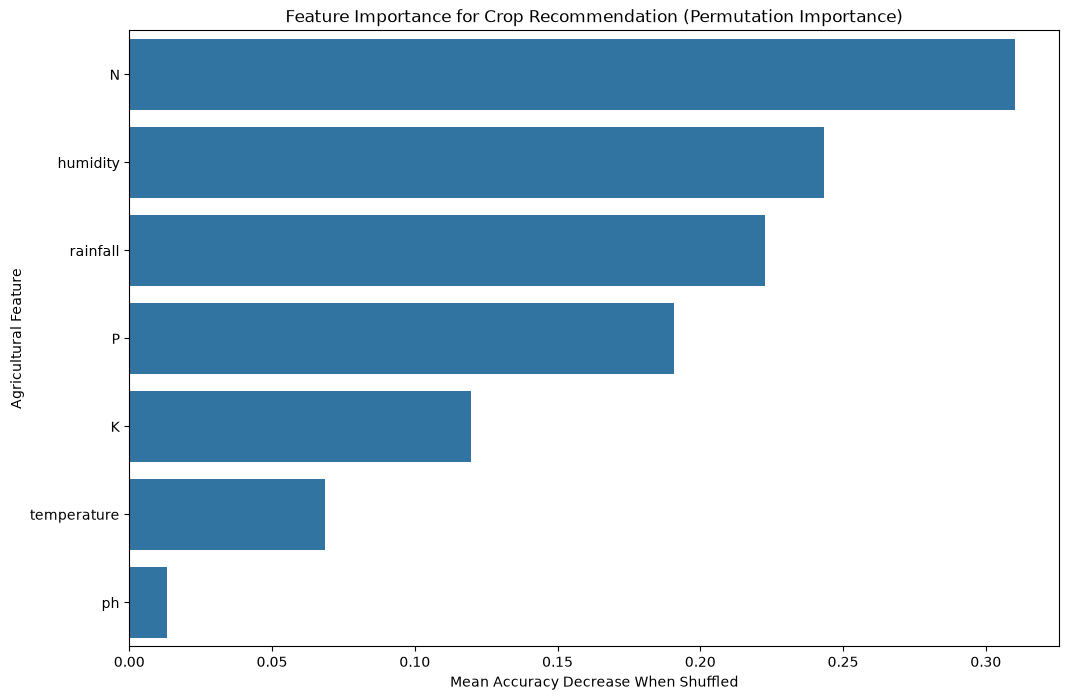

In [1]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

# 2. Load the Best Model and Test Data
model_path = '../models/best_model_crop.pkl'
with open(model_path, 'rb') as f:
    best_model = pickle.load(f)

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Load original labels for plots
le = LabelEncoder()
le.fit(pd.read_csv('../data/crop_data.csv')['label'])
class_names = le.classes_

# 3. Make Predictions
y_pred = best_model.predict(X_test)

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Crop Recommendation Model')
plt.xlabel('Predicted Crop')
plt.ylabel('True Crop')
plt.show()

# 5. Feature Importance Plot
# Uses permutation importance so this works for any model type (not just
# tree-based ones with a native feature_importances_ attribute) - the
# best model selected in 03_model_development.ipynb varies by run/data,
# and a Random-Forest-only check would silently skip this plot otherwise.
perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=1
)
feature_names = X_test.columns

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance for Crop Recommendation (Permutation Importance)')
plt.xlabel('Mean Accuracy Decrease When Shuffled')
plt.ylabel('Agricultural Feature')
plt.show()
